# Question Clustering - Exploratory Data Analysis

Exploratory analysis of question features and distributions from the SeedBench 2+ benchmark.

In [1]:
# Setup: Determine project root
from pathlib import Path
import sys

# Find project root (contains pyproject.toml)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root (pyproject.toml)")
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))

Project root: C:\Users\Andrew\Msc\scale-wise-optimizer


In [2]:
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Ensure NLTK data
for res in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng']:
    try: nltk.data.find(f'tokenizers/{res}' if 'punkt' in res else f'taggers/{res}')
    except LookupError: nltk.download(res, quiet=True)

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Dataset paths
TRAINING_DATASET = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/test_questions.jsonl')
SCORES_FILE = str(PROJECT_ROOT / 'benchmarks/seedbench_2_plus/seedbench_2_plus_resolution_analysis.xlsx')
SCORES_SHEET = 'Consolidated_Scores'

# Resolutions to analyze
RESOLUTIONS = ['2000', '12500', '25000', '50000', '100000', '150000', '250000', '400000', '600000', '800000']

# Question type keywords
QUESTION_TYPES = {
    'counting': ['how many', 'count', 'number of', 'total'],
    'identification': ['which', 'what is', 'identify', 'name'],
    'comparison': ['compare', 'difference', 'larger', 'smaller', 'more', 'less', 'between'],
    'calculation': ['calculate', 'probability', 'percentage', 'ratio', 'fraction'],
    'location': ['where', 'located', 'position', 'region', 'area'],
    'temporal': ['when', 'year', 'date', 'time', 'deadline', 'schedule'],
    'relationship': ['relationship', 'connection', 'link', 'associated', 'related'],
    'visual_reference': ['diagram', 'chart', 'map', 'image', 'screenshot', 'graph', 'table', 'tree']
}

## 1. Data Loading & Preprocessing

In [4]:
# Load questions
questions = []
with open(TRAINING_DATASET, 'r', encoding='utf-8') as f:
    for line in f:
        questions.append(json.loads(line))
df = pd.DataFrame(questions)

# Load resolution scores
df_scores = pd.read_excel(SCORES_FILE, sheet_name=SCORES_SHEET)
df = df.merge(df_scores[['doc_id'] + RESOLUTIONS], on='doc_id', how='left')

# Clean text: remove instruction and options
def clean_input(text):
    text = text.replace("Answer with the option's letter from the given choices directly.", "").strip()
    match = re.search(r'\n[A-D]\.\s', text)
    return text[:match.start()].strip() if match else text

df['question_stem'] = df['input'].apply(clean_input)
print(f"Loaded {len(df)} questions with {len(RESOLUTIONS)} resolutions")

Loaded 2277 questions with 10 resolutions


In [5]:
# Feature extraction
def extract_features(text):
    if not isinstance(text, str) or not text.strip():
        return {k: 0 for k in ['word_count', 'unique_word_ratio', 'noun_count', 'verb_count', 
                               'has_numbers', 'question_complexity'] + [f'is_{t}' for t in QUESTION_TYPES]}
    
    text_lower = text.lower()
    words = nltk.word_tokenize(text_lower)
    word_count = len(words)
    
    features = {
        'word_count': word_count,
        'char_count': len(text),
        'unique_word_ratio': len(set(words)) / max(word_count, 1),
        'has_numbers': 1 if re.search(r'\d', text) else 0,
        'number_count': len(re.findall(r'\d+\.?\d*', text)),
        'math_count': sum(text.count(s) for s in ['+', '-', '^', '=', '{', '}'])
    }
    
    # POS counts
    try:
        tagged = nltk.pos_tag(words)
        pos_counts = Counter(tag for _, tag in tagged)
        features['verb_count'] = sum(c for t, c in pos_counts.items() if t.startswith('VB'))
        features['noun_count'] = sum(c for t, c in pos_counts.items() if t.startswith('NN'))
        features['adj_count'] = sum(c for t, c in pos_counts.items() if t.startswith('JJ'))
    except:
        features['verb_count'] = features['noun_count'] = features['adj_count'] = 0
    
    # Question types
    for qtype, keywords in QUESTION_TYPES.items():
        features[f'is_{qtype}'] = 1 if any(kw in text_lower for kw in keywords) else 0
    
    features['question_complexity'] = word_count * 0.3 + len(set(words)) * 0.3 + features['math_count'] * 0.2
    return features

df_features = pd.DataFrame([extract_features(q) for q in df['question_stem']])
df = pd.concat([df, df_features], axis=1)
print(f"Extracted {len(df_features.columns)} features")

Extracted 18 features


## 2. EDA Summary

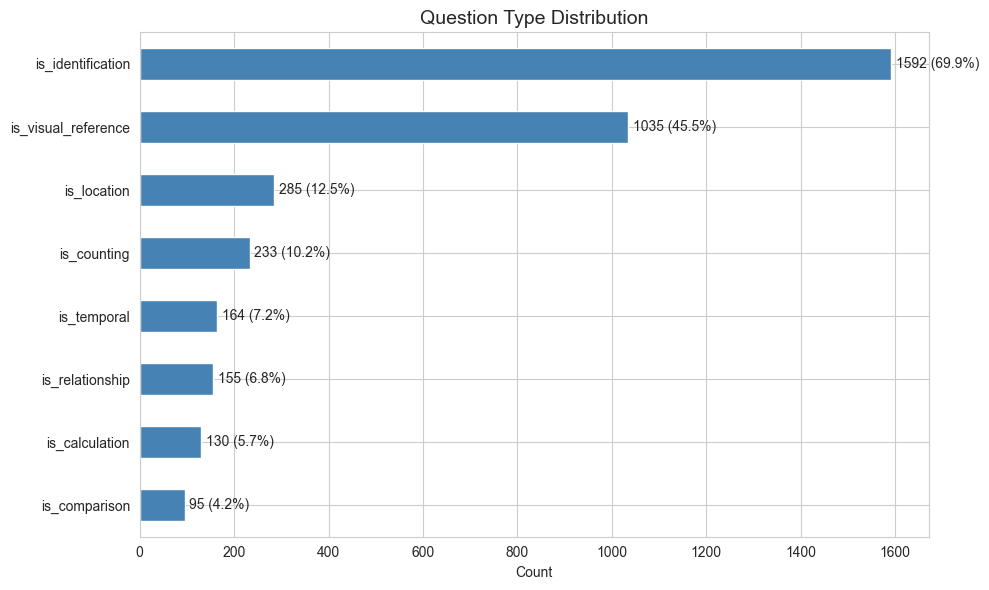

In [6]:
# Question Type Distribution
qtype_cols = [c for c in df.columns if c.startswith('is_')]
qtype_counts = df[qtype_cols].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = qtype_counts.plot(kind='barh', color='steelblue')
plt.title('Question Type Distribution', fontsize=14)
plt.xlabel('Count')
for i, v in enumerate(qtype_counts):
    ax.text(v + 10, i, f'{v} ({v/len(df)*100:.1f}%)', va='center')
plt.tight_layout()
plt.show()

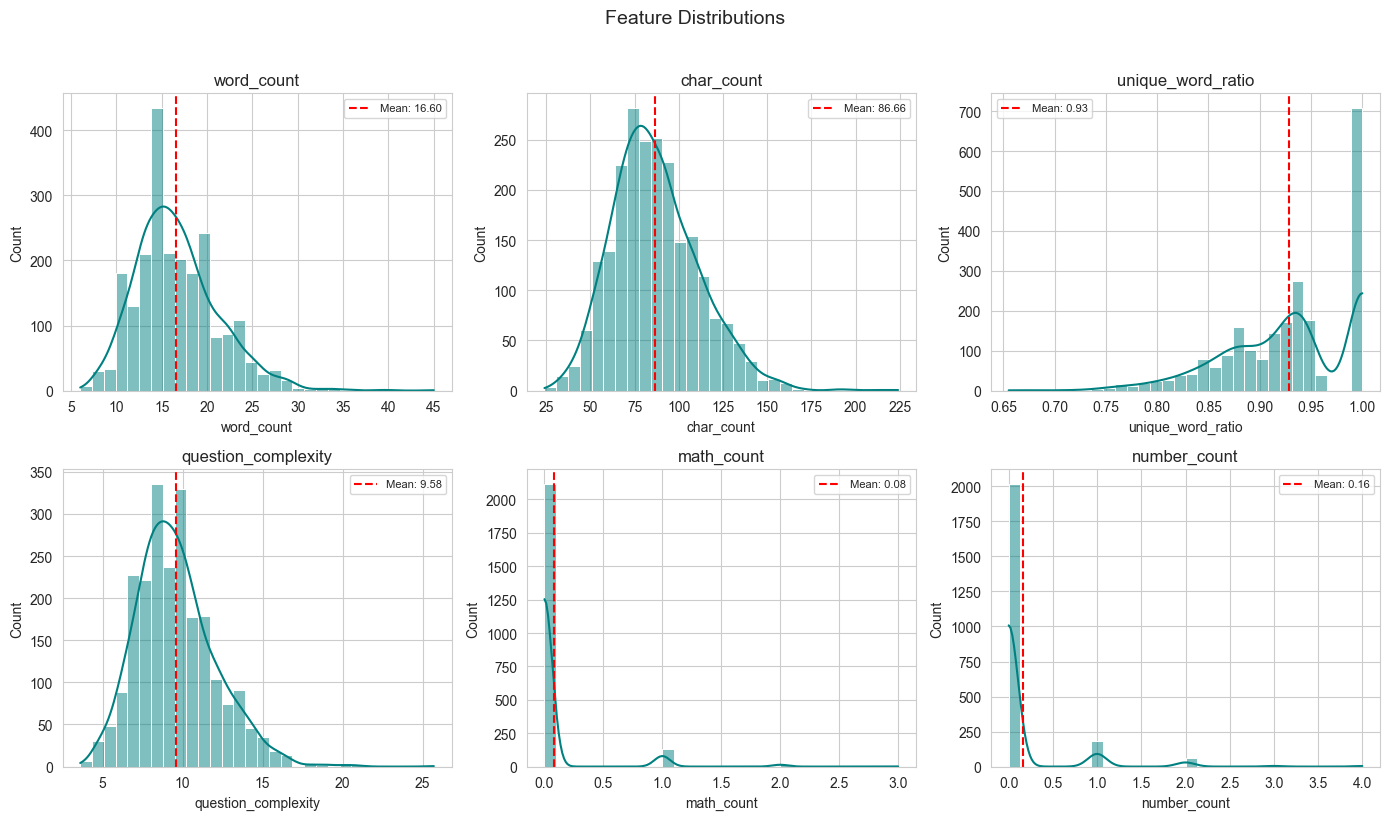

In [7]:
# Feature Distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
metrics = ['word_count', 'char_count', 'unique_word_ratio', 'question_complexity', 'math_count', 'number_count']

for ax, metric in zip(axes.flatten(), metrics):
    sns.histplot(df[metric], ax=ax, kde=True, bins=30, color='teal')
    ax.axvline(df[metric].mean(), color='red', linestyle='--', label=f'Mean: {df[metric].mean():.2f}')
    ax.set_title(metric)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()